# Visualizing the Titanic Disaster

### Introduction:

This exercise is based on the titanic Disaster dataset avaiable at [Kaggle](https://www.kaggle.com/c/titanic).  
To know more about the variables check [here](https://www.kaggle.com/c/titanic/data)


### Step 1. Import the necessary libraries

In [18]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Titanic_Desaster/train.csv)

### Step 3. Assign it to a variable titanic 

In [3]:
lnk = 'https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Titanic_Disaster/train.csv'
titanic = pd.read_csv(lnk)

titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### Step 4. Set PassengerId as the index 

In [4]:
titanic = titanic.set_index('PassengerId')

### Step 5. Create a pie chart presenting the male/female proportion

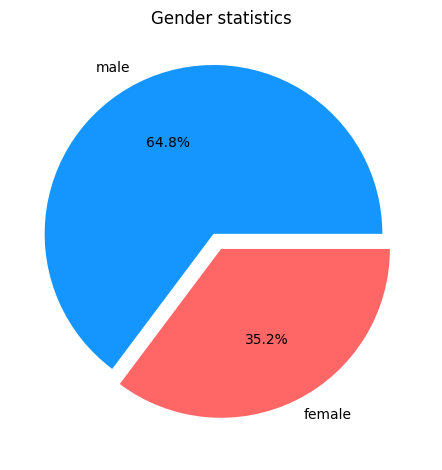

In [81]:
plt.pie(
    x=titanic.Sex.value_counts(), 
    labels=titanic.Sex.unique(),
    colors=['#1596FF', '#FF6767'], 
    autopct='%1.1f%%', 
    explode=(.1, 0)
    );

plt.title('Gender statistics', pad=10)
plt.tight_layout();

### Step 6. Create a scatterplot with the Fare payed and the Age, differ the plot color by gender

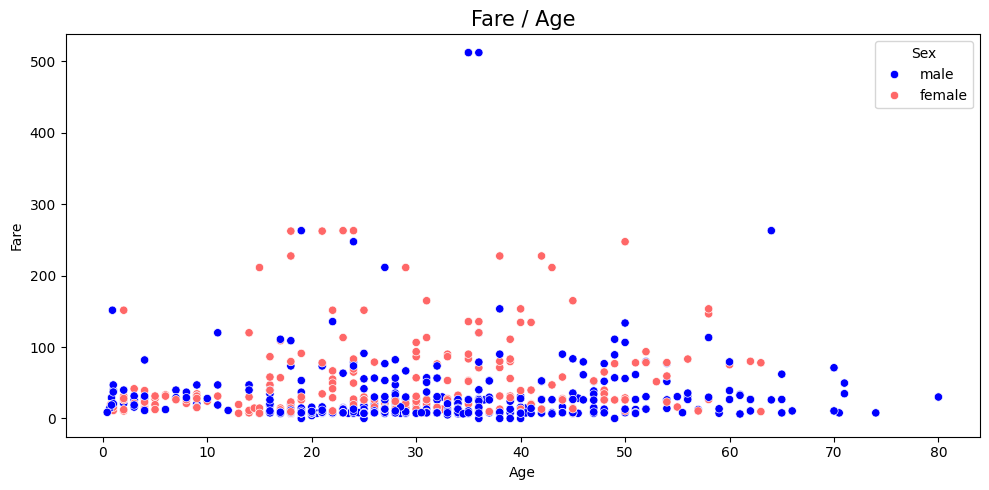

In [84]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=titanic, x='Age', y='Fare',
    hue='Sex', palette=['blue', '#FF6767']
)

plt.title('Fare / Age', fontsize=15)
plt.tight_layout();

### Step 7. How many people survived?

In [31]:
f'{(s := titanic.Survived.sum())} of {(ns := titanic.Survived.count())} people survived ({s / ns * 100:.2f}%)'

'342 of 891 people survived (38.38%)'

### Step 8. Create a histogram with the Fare payed

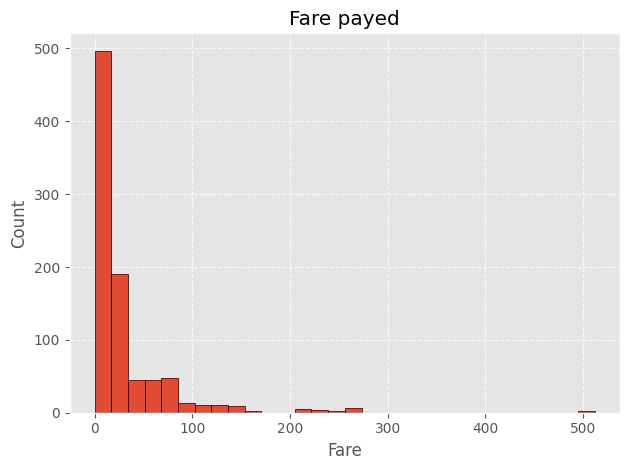

In [101]:
plt.style.use('ggplot')

plt.hist(
    titanic.Fare, 
    bins=30, 
    edgecolor='black', lw=.5
    )

plt.title('Fare payed')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.grid(alpha=.8, ls='--')
plt.tight_layout();

### BONUS: Create your own question and answer it.

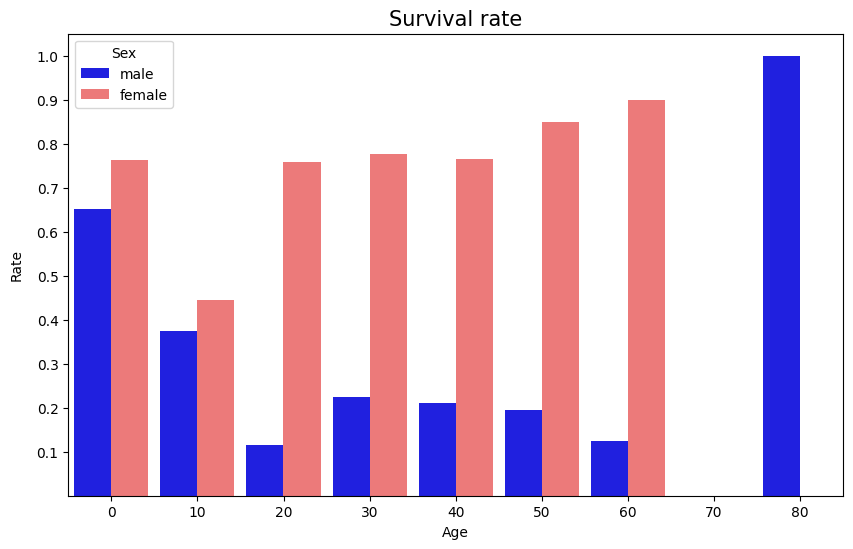

In [103]:
# relationship between survival rate and age w/division by gender

titanic_copy = titanic.copy()
titanic_copy.Age = titanic_copy.Age.round(-1)
age_groups = titanic_copy.groupby(['Age', 'Sex'], as_index=False).agg(
    people_count=('Survived',  'count'),
    survived=('Survived', sum)
)
age_groups['survival_rate'] = age_groups.survived / age_groups.people_count
age_groups.Age = age_groups.Age.astype(int)

plt.style.use('default')

plt.figure(figsize=(10, 6))
sns.barplot(
    data=age_groups, x='Age', y='survival_rate', 
    hue='Sex', hue_order=['male', 'female'], palette=['blue', '#FF6767'], width=.86
)
plt.yticks(ticks=[.1, .2, .3, .4, .5, .6, .7, .8, .9, 1])
plt.title('Survival rate', fontsize=15)
plt.ylabel('Rate', labelpad=9);